In [411]:
import numpy as np 
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
from plotly.subplots import make_subplots
from sklearn.metrics import accuracy_score, classification_report


In [412]:
mob_df = pd.read_excel('files/mob.xlsx')
wine_df = pd.read_csv('files/wine.csv')

In [413]:
mob_df.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


In [414]:
mob_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [415]:
mob_df.head(15)

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1
5,1859,0,0.5,1,3,0,22,0.7,164,1,...,1004,1654,1067,17,1,10,1,0,0,1
6,1821,0,1.7,0,4,1,10,0.8,139,8,...,381,1018,3220,13,8,18,1,0,1,3
7,1954,0,0.5,1,0,0,24,0.8,187,4,...,512,1149,700,16,3,5,1,1,1,0
8,1445,1,0.5,0,0,0,53,0.7,174,7,...,386,836,1099,17,1,20,1,0,0,0
9,509,1,0.6,1,2,1,9,0.1,93,5,...,1137,1224,513,19,10,12,1,0,0,0


battery_power: Мощность батареи в мАч (миллиампер-часах).

blue: Наличие Bluetooth (1 — есть, 0 — нет).

clock_speed: Тактовая частота процессора в GHz.

dual_sim: Наличие двух SIM-карт (1 — есть, 0 — нет).

fc: Количество мегапикселей фронтальной камеры.

four_g: Наличие поддержки 4G (1 — есть, 0 — нет).

int_memory: Внутренная память в гигабайтах.

m_dep: Глубина мобильного устройства (в сантиметрах).

mobile_wt: Вес мобильного устройства в граммах.

n_cores: Количество ядер процессора.

px_height: Высота экрана в пикселях.

px_width: Ширина экрана в пикселях.

ram: Оперативная память в мегабайтах.

sc_h: Высота экрана в дюймах.

sc_w: Ширина экрана в дюймах.

talk_time: Время разговора в часах.

three_g: Наличие поддержки 3G (1 — есть, 0 — нет).

touch_screen: Наличие сенсорного экрана (1 — есть, 0 — нет).

wifi: Наличие Wi-Fi (1 — есть, 0 — нет).

price_range: Ценовой диапазон телефона (например, 1 — дешевый, 2 — средний, 3 — дорогой, 4 — очень дорогой).

In [416]:
corr_matrix = mob_df.corr(numeric_only=True)

fig = px.imshow(corr_matrix,
                width=1500,
                height=1500,
                text_auto=True, aspect="auto",
                color_continuous_scale='RdBu_r',
                )
fig.update_layout(width=1000, height=800)
fig.update_layout(title='Correlation Matrix')
fig.show()

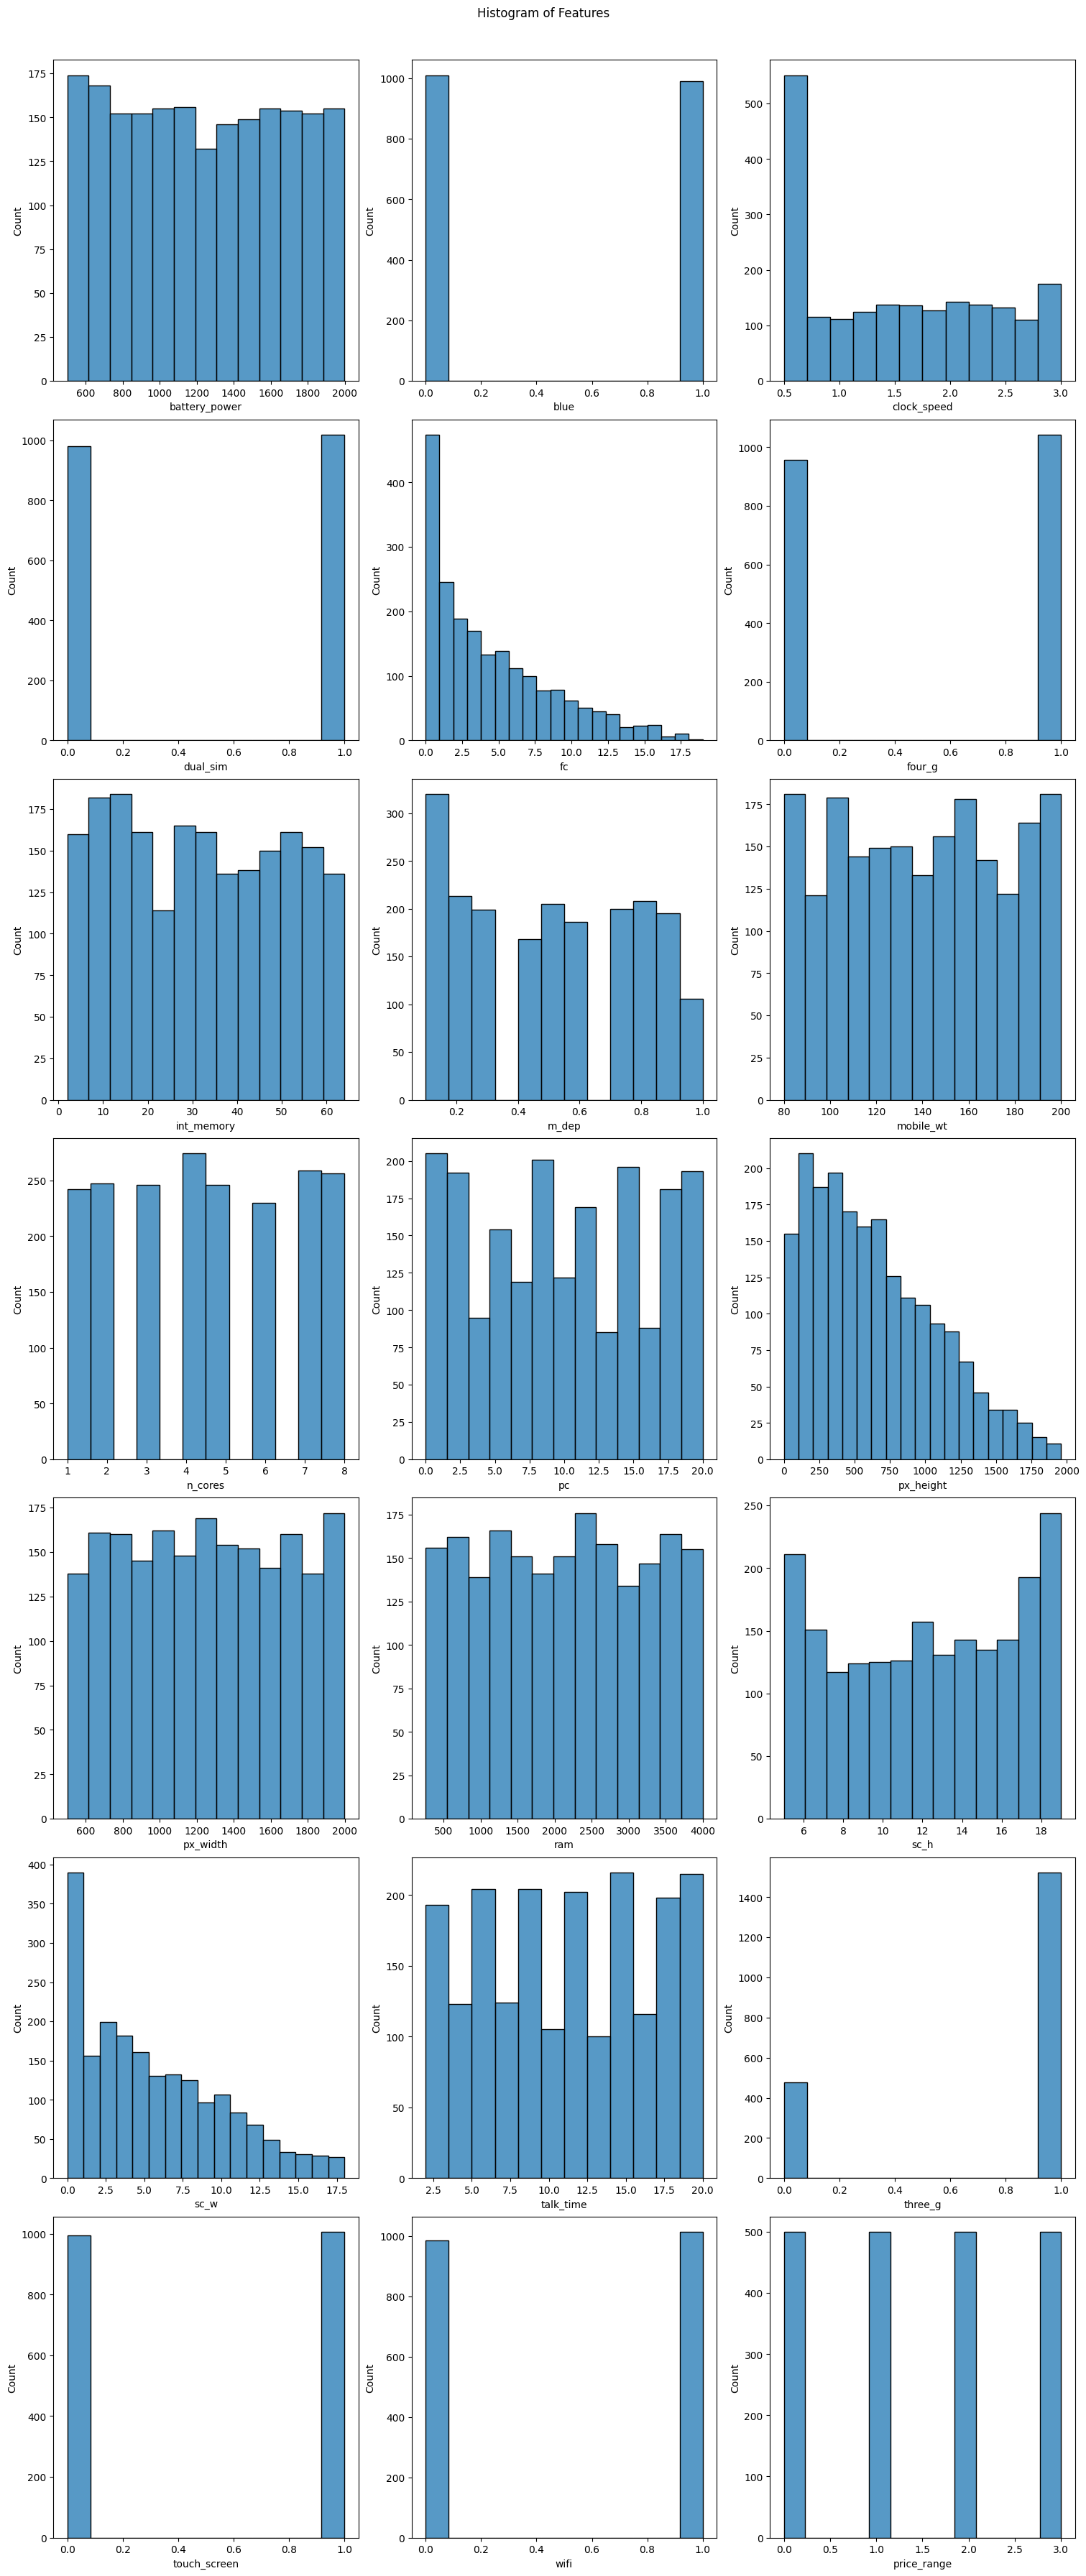

In [417]:
features = mob_df.columns.tolist()

rows = (len(features) + 2) // 3
cols = 3

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows), constrained_layout=True)

axes = axes.flatten()

for i, feature in enumerate(features):
    sns.histplot(mob_df[feature], ax=axes[i], kde=False)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Histogram of Features', y=1.02)
plt.show()

In [418]:
X = mob_df.drop("price_range", axis=1)
y = mob_df["price_range"]

In [419]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

X_train, _X, y_train, _y = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(_X, _y, train_size=0.5, random_state=42)

scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [420]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

predictions_train_log = log_model.predict(X_train_scaled)
predictions_val_log = log_model.predict(X_val_scaled)
predictions_test_log = log_model.predict(X_test_scaled)

In [422]:
print(classification_report(y_test, predictions_test_log))


              precision    recall  f1-score   support

           0       0.99      0.96      0.98       108
           1       0.92      0.98      0.95        96
           2       0.98      0.94      0.96       103
           3       0.98      0.99      0.98        93

    accuracy                           0.97       400
   macro avg       0.97      0.97      0.97       400
weighted avg       0.97      0.97      0.97       400



In [424]:
print(classification_report(y_val, predictions_val_log))

              precision    recall  f1-score   support

           0       0.98      0.97      0.97        94
           1       0.93      0.98      0.96        98
           2       0.98      0.92      0.95        99
           3       0.96      0.98      0.97       109

    accuracy                           0.96       400
   macro avg       0.96      0.96      0.96       400
weighted avg       0.96      0.96      0.96       400



In [421]:
print(classification_report(y_train, predictions_train_log))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       298
           1       0.97      0.96      0.97       306
           2       0.97      0.97      0.97       298
           3       0.98      0.99      0.98       298

    accuracy                           0.97      1200
   macro avg       0.97      0.98      0.98      1200
weighted avg       0.97      0.97      0.97      1200



In [425]:
depth_train_list = []
depth_val_list = []

max_depth_list = np.linspace(1,30,20).astype(int)
for max_depth in max_depth_list:
    model = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    model.fit(X_train_scaled, y_train)
    
    predictions_train = model.predict(X_train_scaled)
    predictions_val = model.predict(X_val_scaled)
    
    accuracy_score_train = accuracy_score(y_train, predictions_train)
    accuracy_score_val = accuracy_score(y_val, predictions_val)
    
    depth_train_list.append(accuracy_score_train)
    depth_val_list.append(accuracy_score_val)

Text(0, 0.5, 'Accuracy')

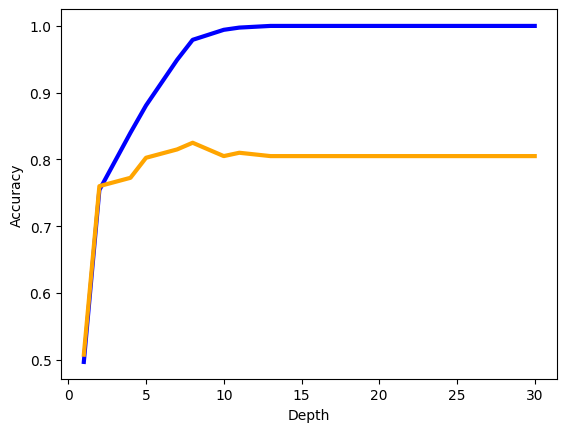

In [426]:
plt.plot(max_depth_list, depth_train_list, color = 'blue', linewidth = 3)
plt.plot(max_depth_list, depth_val_list, color = 'orange', linewidth = 3)
plt.xlabel('Depth')
plt.ylabel('Accuracy')

In [427]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(max_depth=5,criterion="entropy",random_state=42)
dt_model.fit(X_train_scaled, y_train)

predictions_val_dt = dt_model.predict(X_val_scaled)
predictions_test_dt = dt_model.predict(X_test_scaled)

In [428]:
print(classification_report(y_test, predictions_test_dt))

              precision    recall  f1-score   support

           0       0.87      0.94      0.90       108
           1       0.75      0.79      0.77        96
           2       0.81      0.71      0.76       103
           3       0.88      0.87      0.88        93

    accuracy                           0.83       400
   macro avg       0.83      0.83      0.83       400
weighted avg       0.83      0.83      0.83       400



In [429]:
print(classification_report(y_val, predictions_val_dt))

              precision    recall  f1-score   support

           0       0.85      0.94      0.89        94
           1       0.78      0.84      0.81        98
           2       0.86      0.67      0.75        99
           3       0.87      0.91      0.89       109

    accuracy                           0.84       400
   macro avg       0.84      0.84      0.83       400
weighted avg       0.84      0.84      0.83       400



In [430]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(criterion="entropy", max_depth = 13)
rf_model.fit(X_train_scaled, y_train)

predictions_val_rf = rf_model.predict(X_val_scaled)
predictions_test_rf = rf_model.predict(X_test_scaled)

In [431]:
print(classification_report(y_test, predictions_test_rf))

              precision    recall  f1-score   support

           0       0.97      0.94      0.96       108
           1       0.84      0.90      0.87        96
           2       0.84      0.83      0.83       103
           3       0.91      0.90      0.91        93

    accuracy                           0.89       400
   macro avg       0.89      0.89      0.89       400
weighted avg       0.89      0.89      0.89       400



In [432]:
print(classification_report(y_val, predictions_val_rf))

              precision    recall  f1-score   support

           0       0.94      0.95      0.94        94
           1       0.84      0.91      0.87        98
           2       0.88      0.79      0.83        99
           3       0.92      0.93      0.92       109

    accuracy                           0.89       400
   macro avg       0.89      0.89      0.89       400
weighted avg       0.89      0.89      0.89       400



In [433]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from sklearn.metrics import mean_squared_error
from tensorflow.keras.utils import to_categorical

y_train_onehot = to_categorical(y_train)
y_test_onehot = to_categorical(y_test)
y_val_onehot = to_categorical(y_val)

out_count = len(mob_df['price_range'].unique())

k_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dense(32, activation='relu'),
    Dense(64, activation='sigmoid'),
    Dropout(0.2),
    Dense(out_count, activation='softmax')
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

k_model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
history = k_model.fit(X_train_scaled, y_train_onehot, epochs=17, batch_size=32, validation_data=(X_val_scaled, y_val_onehot))

Epoch 1/17
38/38 [==============================] - 1s 8ms/step - loss: 1.4392 - accuracy: 0.2892 - val_loss: 1.3290 - val_accuracy: 0.4225
Epoch 2/17
38/38 [==============================] - 0s 3ms/step - loss: 1.2471 - accuracy: 0.4333 - val_loss: 1.1849 - val_accuracy: 0.5625
Epoch 3/17
38/38 [==============================] - 0s 3ms/step - loss: 1.0351 - accuracy: 0.5667 - val_loss: 0.9445 - val_accuracy: 0.7225
Epoch 4/17
38/38 [==============================] - 0s 3ms/step - loss: 0.8221 - accuracy: 0.6792 - val_loss: 0.7505 - val_accuracy: 0.7875
Epoch 5/17
38/38 [==============================] - 0s 3ms/step - loss: 0.6867 - accuracy: 0.7442 - val_loss: 0.6272 - val_accuracy: 0.8275
Epoch 6/17
38/38 [==============================] - 0s 3ms/step - loss: 0.5925 - accuracy: 0.7750 - val_loss: 0.5361 - val_accuracy: 0.8725
Epoch 7/17
38/38 [==============================] - 0s 3ms/step - loss: 0.5365 - accuracy: 0.8075 - val_loss: 0.4677 - val_accuracy: 0.9025
Epoch 8/17
38/38 [==

In [434]:
predictions_test_k = k_model.predict(X_test_scaled)
predictions_val_k = k_model.predict(X_val_scaled)

13/13 [==============================] - 0s 1ms/step


In [435]:
y_test_int = np.argmax(y_test_onehot, axis=1)
y_val_int = np.argmax(y_val_onehot, axis=1)

predictions_test_k = np.argmax(predictions_test_k, axis=1)
predictions_val_k = np.argmax(predictions_val_k, axis=1)

print("Test set classification report:")
print(classification_report(y_test_int, predictions_test_k))

print("\nValidation set classification report:")
print(classification_report(y_val_int, predictions_val_k))

Test set classification report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       108
           1       0.88      0.88      0.88        96
           2       0.93      0.85      0.89       103
           3       0.91      0.99      0.95        93

    accuracy                           0.92       400
   macro avg       0.91      0.92      0.91       400
weighted avg       0.92      0.92      0.91       400


Validation set classification report:
              precision    recall  f1-score   support

           0       0.94      0.95      0.94        94
           1       0.88      0.91      0.89        98
           2       0.92      0.84      0.88        99
           3       0.92      0.96      0.94       109

    accuracy                           0.92       400
   macro avg       0.92      0.91      0.91       400
weighted avg       0.92      0.92      0.91       400



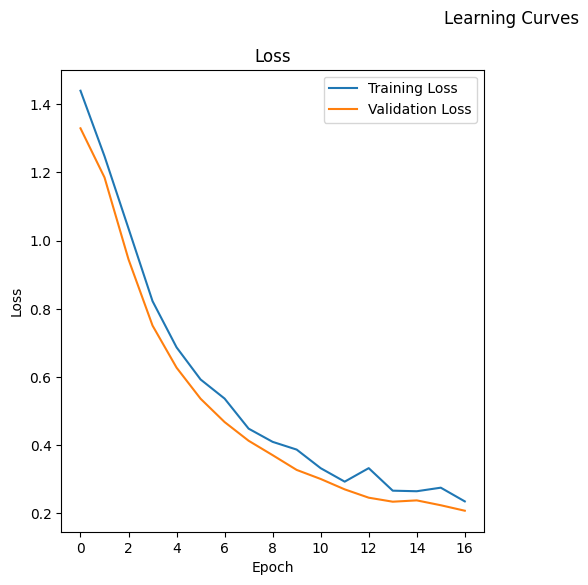

In [436]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.suptitle('Learning Curves')
plt.show()

In [437]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=1.0, max_depth=3, random_state=42)
gb_model.fit(X_train_scaled, y_train)

GradientBoostingClassifier(learning_rate=1.0, random_state=42)

In [438]:
predictions_val_gb = gb_model.predict(X_val_scaled)
predictions_test_gb = gb_model.predict(X_test_scaled)

In [439]:
print(classification_report(y_test, predictions_test_gb))

              precision    recall  f1-score   support

           0       0.95      0.94      0.95       108
           1       0.89      0.86      0.88        96
           2       0.84      0.89      0.86       103
           3       0.92      0.89      0.91        93

    accuracy                           0.90       400
   macro avg       0.90      0.90      0.90       400
weighted avg       0.90      0.90      0.90       400



In [440]:
print(classification_report(y_val, predictions_val_gb))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96        94
           1       0.88      0.91      0.89        98
           2       0.85      0.82      0.84        99
           3       0.91      0.92      0.91       109

    accuracy                           0.90       400
   macro avg       0.90      0.90      0.90       400
weighted avg       0.90      0.90      0.90       400

